### TNCDR-mitigating Qiskit results

Retrieve results on IBM machine, compute exact expectation values using hybrid stabilizers-MPO and execute data-driven error mitigation with these data.

In [1]:
import os, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Qibo related stuff
from qibo import set_backend
from qibo import symbols, hamiltonians

# Qiskit related stuff
from qiskit_ibm_runtime import RuntimeDecoder
from mpstab.targets.ansatze import FloquetAnsatz, TranspiledAnsatz
from mpstab.evolutors.models import HybridSurrogate

In [2]:
# Set Qibo backend, for a double check
set_backend("qibojit", platform="numba")

path = "41q_2l"

[Qibo 0.2.20|INFO|2025-08-05 09:52:33]: Using qibojit (numba) backend on /CPU:0


In [5]:
# Loading results from hardware run
with open(f"{path}/results/tncdr_results_twirlFalse.json", "r") as file:
    result = json.load(file, cls=RuntimeDecoder)

values = []
for res in result:
    values.append(res.data.evs)

In [6]:
result.metadata

{'dynamical_decoupling': {'enable': True,
  'sequence_type': 'XpXm',
  'extra_slack_distribution': 'middle',
  'scheduling_method': 'alap'},
 'twirling': {'enable_gates': False,
  'enable_measure': True,
  'num_randomizations': 'auto',
  'shots_per_randomization': 'auto',
  'interleave_randomizations': True,
  'strategy': 'active-accum'},
 'resilience': {'measure_mitigation': True,
  'zne_mitigation': False,
  'pec_mitigation': False},
 'version': 2}

In [7]:
result[0].data

DataBin(evs=np.ndarray(<shape=(), dtype=float64>), stds=np.ndarray(<shape=(), dtype=float64>), ensemble_standard_error=np.ndarray(<shape=(), dtype=float64>))

In [8]:
# Let's visualize them
print(values)

[array(0.15855767), array(0.20910499), array(0.29910687), array(0.32399678), array(0.1126204), array(0.4842639), array(0.3961472), array(0.3971351), array(0.50697962), array(0.46263971), array(0.3715874), array(0.23199159), array(0.06153846), array(0.14503441), array(0.563102), array(0.25833539), array(-0.03338316), array(0.21797682), array(0.52492779), array(-0.00941876), array(0.15433129)]


(array([2., 1., 2., 2., 4., 2., 1., 2., 2., 3.]),
 array([-0.03338316,  0.02626536,  0.08591387,  0.14556239,  0.2052109 ,
         0.26485942,  0.32450794,  0.38415645,  0.44380497,  0.50345348,
         0.563102  ]),
 <BarContainer object of 10 artists>)

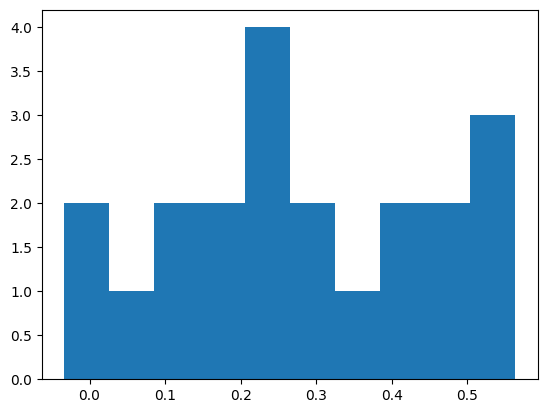

In [9]:
plt.hist(values)

In [10]:
# Loading the configuration to reconstruct the ansatz
with open(f"{path}/config.json") as f:
    config = json.load(f)

print(config)

{'nqubits': 41, 'nlayers': 2, 'b': 1.2566370614359172, 'theta': 1.5707963267948966, 'replacement_probability': 0.8, 'ncircuits': 20, 'random_seed': 42, 'local_pauli_noise_sigma': 0.003, 'max_bond_dimension': 128, 'nruns': 10, 'plot': True, 'save_results': True}


In [11]:
# detect training parameter files
path = Path(path)
param_files = sorted((path / "circuits").glob("params_circuit*.npy"))
# Load all the executed circuits' parameters
circuit_params = []
for p in param_files:
    print(p)
    circuit_params.append(np.load(p))

41q_2l/circuits/params_circuit0.npy
41q_2l/circuits/params_circuit1.npy
41q_2l/circuits/params_circuit10.npy
41q_2l/circuits/params_circuit11.npy
41q_2l/circuits/params_circuit12.npy
41q_2l/circuits/params_circuit13.npy
41q_2l/circuits/params_circuit14.npy
41q_2l/circuits/params_circuit15.npy
41q_2l/circuits/params_circuit16.npy
41q_2l/circuits/params_circuit17.npy
41q_2l/circuits/params_circuit18.npy
41q_2l/circuits/params_circuit19.npy
41q_2l/circuits/params_circuit2.npy
41q_2l/circuits/params_circuit3.npy
41q_2l/circuits/params_circuit4.npy
41q_2l/circuits/params_circuit5.npy
41q_2l/circuits/params_circuit6.npy
41q_2l/circuits/params_circuit7.npy
41q_2l/circuits/params_circuit8.npy
41q_2l/circuits/params_circuit9.npy


In [12]:
# Construct Floquet inspired ansatz and related transpiled one
floq_ansatz = FloquetAnsatz(
    nqubits=config["nqubits"],
    nlayers=config["nlayers"],
    b=config["b"],
    theta=config["theta"],
    target_qubit=int(config["nqubits"]/2)
)

print(floq_ansatz.circuit.summary())

Circuit depth = 42
Total number of gates = 1122
Number of qubits = 41
Most common gates:
rz: 481
rx: 320
cx: 320
h: 1


In [13]:
# Construct observable
# Target qubit
q = int(config["nqubits"]/2)
obs = "I" * (q) + "X" + "I" * (config["nqubits"] - (q + 1))
print(obs)

IIIIIIIIIIIIIIIIIIIIXIIIIIIIIIIIIIIIIIIII


In [ ]:
# Construct hybrid surrogate and test it
hs = HybridSurrogate(ansatz=floq_ansatz, max_bond_dimension=64)

# repl_prob = 0. means we leave it as it is
expval_boss, _  = hs.expectation_from_partition(
    observable=obs,
    replacement_probability=0.,
)

print(expval_boss)

In [15]:
# Construct the symbolic form from the observable pauli operators
form = 1
for i, pauli in enumerate(obs):
    form *= getattr(symbols, pauli)(i)

if config["nqubits"] <= 30:
    # The correspondent hamiltonian
    ham = hamiltonians.SymbolicHamiltonian(form)
    # And execute expval as double check
    expval_boss = ham.expectation(floq_ansatz.circuit().state())
    expval_boss

[Qibo 0.2.20|ERROR|2025-08-05 09:54:00]: State does not fit in /CPU:0 memory.Please switch the execution device to a different one using ``qibo.set_device``.


RuntimeError: State does not fit in /CPU:0 memory.Please switch the execution device to a different one using ``qibo.set_device``.

#### Compute exact expectation values using our simulator

In [15]:
values[0], 2**(config["nqubits"]//2)

(array(0.14081028), 4096)

In [ ]:
exact_values = []
for i, par in enumerate(circuit_params):
    # Update Floquet ansatz
    floq_ansatz.circuit.set_parameters(par)
    # Construct surrogate
    hs = HybridSurrogate(floq_ansatz, max_bond_dimension=128)
    # Compute expectation value
    exact_val = hs.expectation_from_partition(observable=obs, replacement_probability=0.)[0]
    exact_values.append(exact_val)
    print(f"Exact value for params {i+1}/20: {exact_val}, while noisy value is: {values[i+1]}")

theta:  1.5707963267948966


In [22]:
def line(x, a, b):
    """Linear ansatz"""
    return x * a + b

def plot_mitigation(exact_values, noisy_values, line_params=None):
    """Plot mitigation results"""
    plt.figure(figsize=(5, 5*6/8), dpi=100)
    plt.scatter(noisy_values, exact_values, color="purple", label="Data")
    if line_params is not None:
        x = np.linspace(min(noisy_values), max(noisy_values), 100)
        y = line(x, *line_params)
        plt.plot(x, y, color="black", label="Fit", ls="-")
    plt.xlabel("IBM hardware")
    plt.ylabel("Exact")
    plt.legend()
    plt.grid()

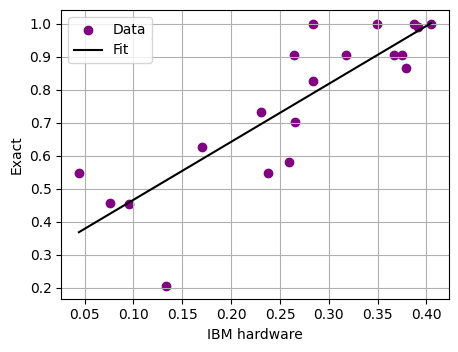

In [23]:
# Adopt a linear map and fit the data
popt, pcov = curve_fit(line, values[1:], exact_values)
popt

# Show the results in a plot
plot_mitigation(exact_values, values[1:], popt)

In [24]:
# Show the results in numbers
noisy_value = values[0]
exact_value = expval_boss

print(f"Noisy: {noisy_value}")
print(f"Exact: {exact_value}")
print(f"Mitig: {line(noisy_value, *popt)}")
print(f"\nMSE noisy: {(noisy_value-exact_value)**2}")
print(f"MSE mitig: {(line(noisy_value, *popt)-exact_value)**2}")

Noisy: 0.1408102766798419
Exact: 0.5501106913269282
Mitig: 0.5380678639258696

MSE noisy: 0.1675268294302768
MSE mitig: 0.0001450296918116894
